# ACO for CVRP — Experiment Analysis

Comparative analysis of Greedy, ACO, EAS, and MMAS on CVRPLIB A-series instances.

In [1]:
%matplotlib inline
import json
import pathlib
import sys

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from src.viz import plot_routes, plot_convergence, plot_boxplots, plot_scaling
from src.metrics import iterations_to_delta, stagnation_length

RESULTS_DIR  = pathlib.Path("../results/main")
SMAX_DIR_32  = pathlib.Path("../results/smax_32")
SMAX_DIR_45  = pathlib.Path("../results/smax_45")

df = pd.read_csv(RESULTS_DIR / "results.csv")
df["feasible"] = df["feasible"].astype(bool)
df["relative_error"] = pd.to_numeric(df["relative_error"], errors="coerce")
df["s_max"] = pd.to_numeric(df["s_max"], errors="coerce")

main = df[df["feasible"] & df["s_max"].isna()]
print(f"Loaded {len(df)} total runs, {len(main)} feasible unconstrained")

Loaded 240 total runs, 230 feasible unconstrained


## H3.1 — Solution Quality

Compare mean relative error vs best-known across algorithms. Box plots show distribution across seeds.

=== Mean relative error vs best known (lower is better) ===


,Mean RE,Std RE,Best RE
algorithm,,,
aco,NaN,NaN,NaN
eas,NaN,NaN,NaN
greedy,NaN,NaN,NaN
mmas,NaN,NaN,NaN



=== Mean total distance per instance ===


algorithm,aco,eas,greedy,mmas
instance,,,,
A-n32-k5,872.4,866.9,1146.4,959.7
A-n37-k6,1127.7,1061.7,1341.9,1196.3
A-n45-k6,1089.2,1078.6,NaN,1195.2
A-n55-k9,1322.3,1297.2,1499.3,1390.0
A-n60-k9,1659.4,1633.3,1970.0,1768.3
A-n80-k10,2177.5,2126.7,2255.5,2349.4


TypeError: Axes.boxplot() got an unexpected keyword argument 'title'

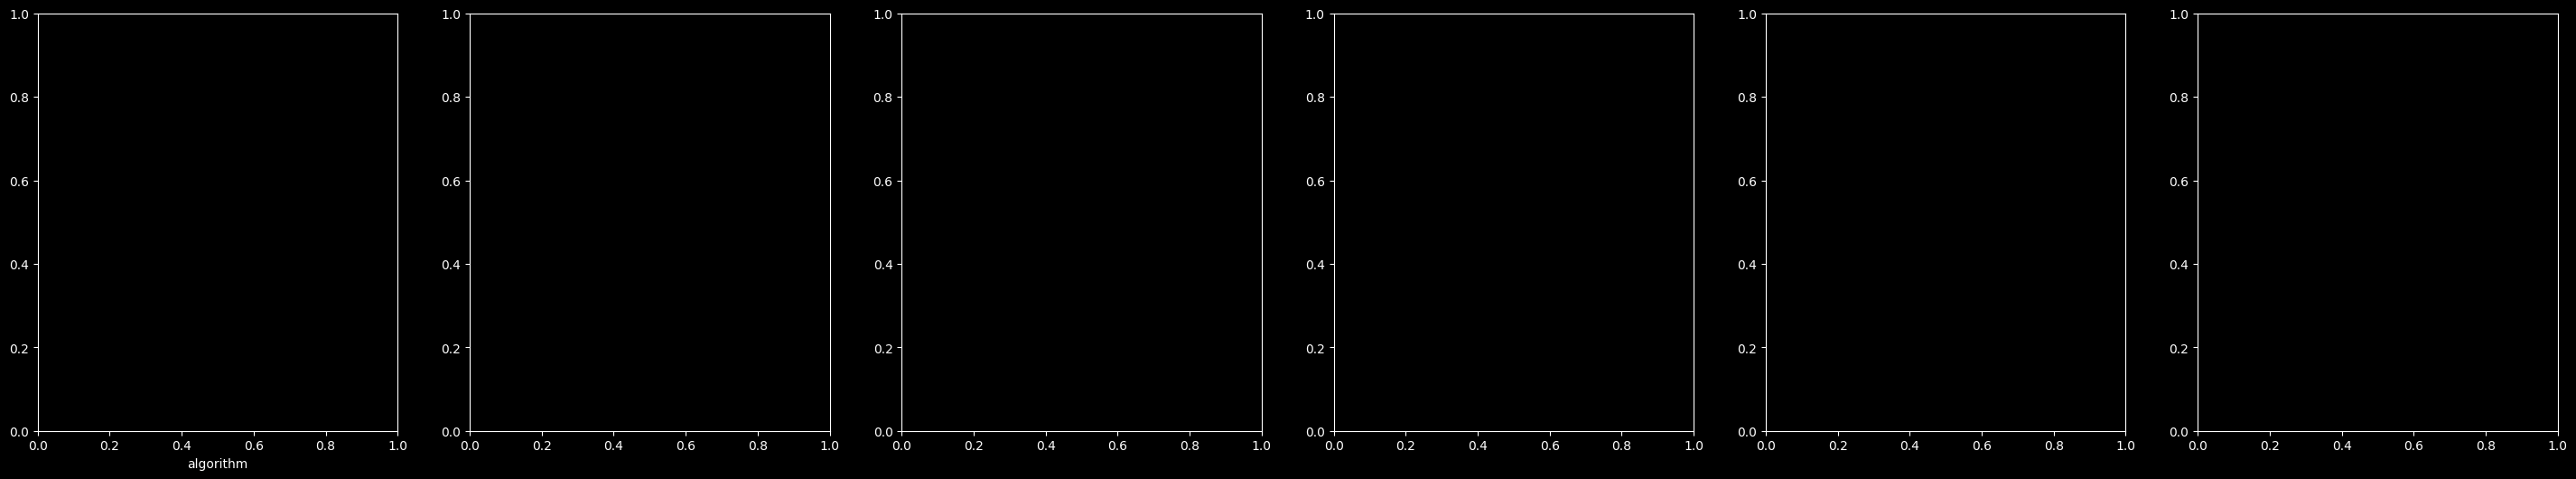

In [2]:
print("=== Mean relative error vs best known (lower is better) ===")
display(
    main.groupby("algorithm")["relative_error"]
    .agg(["mean", "std", "min"])
    .rename(columns={"mean": "Mean RE", "std": "Std RE", "min": "Best RE"})
    .round(4)
    .sort_values("Mean RE")
)

print("\n=== Mean total distance per instance ===")
display(
    main.groupby(["algorithm", "instance"])["total_dist"]
    .mean()
    .round(1)
    .unstack("algorithm")
)

plot_boxplots(main)

## H3.2 — Scalability

Relative error and runtime vs instance size (number of customers).

No feasible runs with known best solutions found for scaling plot.


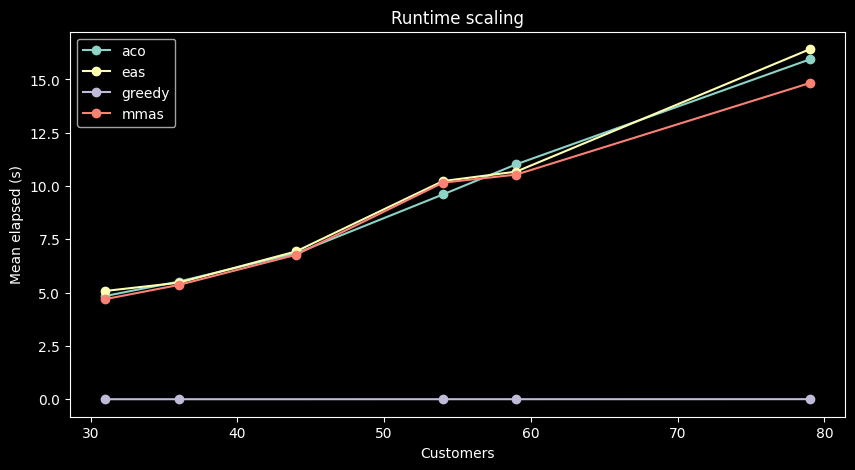

In [3]:
plot_scaling(main)

elapsed = (
    main.groupby(["algorithm", "n_customers"])["elapsed_sec"]
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))
for algo in elapsed["algorithm"].unique():
    g = elapsed[elapsed["algorithm"] == algo].sort_values("n_customers")
    ax.plot(g["n_customers"], g["elapsed_sec"], "-o", label=algo)
ax.set_xlabel("Customers")
ax.set_ylabel("Mean elapsed (s)")
ax.set_title("Runtime scaling")
ax.legend()

## H3.3 — Convergence

Iterations to 20% improvement, stagnation length, and convergence curves.

iter_to_20pct  stagnation
algorithm instance                            
aco       A-n32-k5            36.9        68.4
          A-n37-k6             NaN        93.9
          A-n45-k6            81.7        80.5
          A-n55-k9             NaN        77.5
          A-n60-k9             NaN        87.3
          A-n80-k10            NaN        87.0
eas       A-n32-k5            13.9        88.8
          A-n37-k6            65.5        63.1
          A-n45-k6            56.6        91.0
          A-n55-k9             NaN        64.4
          A-n60-k9             NaN        66.8
          A-n80-k10           67.0        77.7
mmas      A-n32-k5            56.3       111.7
          A-n37-k6             NaN        81.3
          A-n45-k6             NaN       123.4
          A-n55-k9             NaN        70.9
          A-n60-k9             NaN       130.2
          A-n80-k10            NaN        78.1

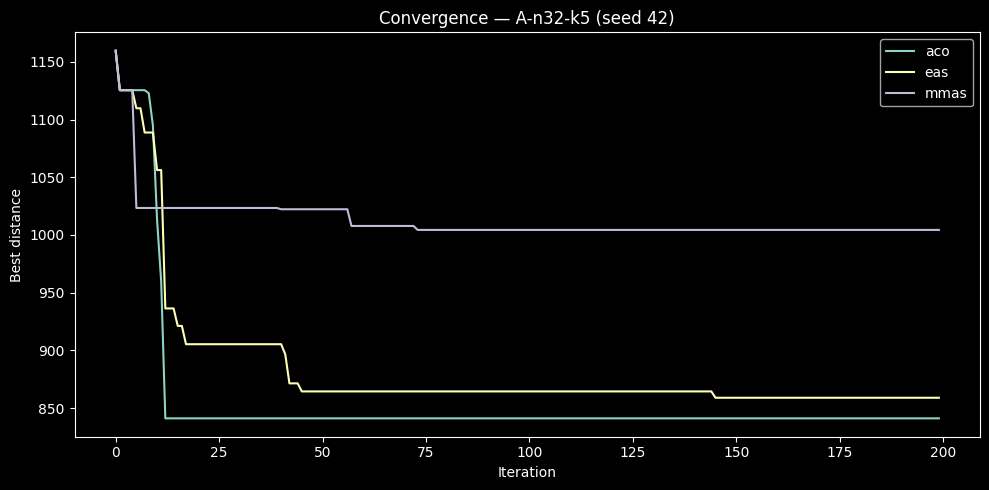

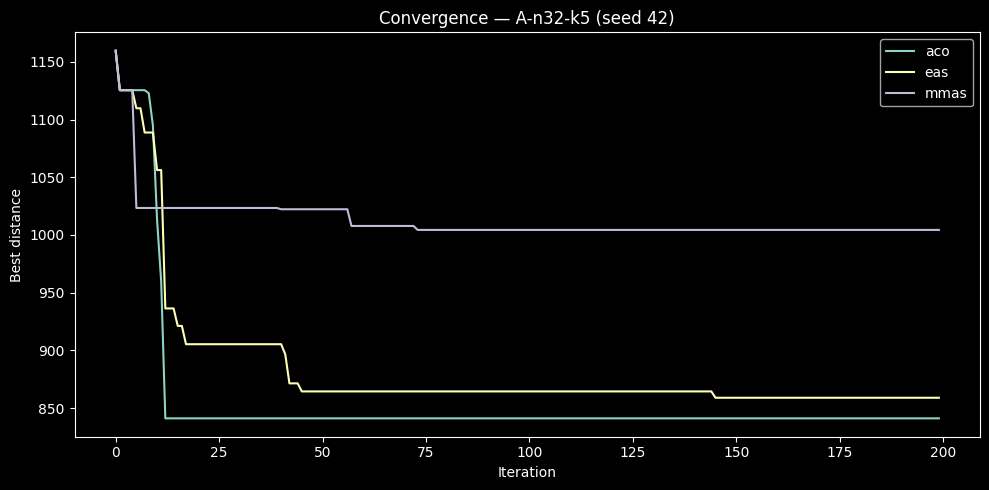

In [4]:
records = []
for jf in RESULTS_DIR.glob("*.json"):
    run = json.loads(jf.read_text())
    if not run.get("convergence") or run["algorithm"] == "greedy":
        continue
    records.append({
        "algorithm":    run["algorithm"],
        "instance":     run["instance"],
        "seed":         run["seed"],
        "iter_to_20pct": iterations_to_delta(run["convergence"], delta=0.20),
        "stagnation":   stagnation_length(run["convergence"]),
    })

conv_df = pd.DataFrame(records)
display(
    conv_df.groupby(["algorithm", "instance"])[["iter_to_20pct", "stagnation"]]
    .mean()
    .round(1)
)

target = "A-n32-k5"
curves = {}
for jf in RESULTS_DIR.glob("*.json"):
    run = json.loads(jf.read_text())
    if run["instance"] == target and run["seed"] == 42 and run.get("convergence"):
        curves[run["algorithm"]] = run["convergence"]

plot_convergence(curves, f"Convergence — {target} (seed 42)")

## H3.4 — S_max and α/β Sensitivity

How tight distance constraints shift the optimal α/β parametrisation.

In [5]:
sw = pd.concat([
    pd.read_csv(SMAX_DIR_32 / "results.csv"),
    pd.read_csv(SMAX_DIR_45 / "results.csv"),
], ignore_index=True)
sw["feasible"] = sw["feasible"].astype(bool)
sw["relative_error"] = pd.to_numeric(sw["relative_error"], errors="coerce")
sw["s_max"] = pd.to_numeric(sw["s_max"], errors="coerce")

for s_label, mask in [("Unconstrained", sw["s_max"].isna()), ("Constrained", sw["s_max"].notna())]:
    sub = sw[mask & sw["feasible"]]
    if sub.empty:
        print(f"{s_label}: no feasible runs")
        continue
    best = (
        sub.groupby(["algorithm", "param_alpha", "param_beta"])["relative_error"]
        .mean()
        .sort_values()
    )
    print(f"\n=== {s_label} — top 5 α/β combos by mean relative error ===")
    display(best.head(5).round(4).to_frame())

print("\n=== Feasibility rate ===")
display(
    sw.groupby(["algorithm", sw["s_max"].isna().map({True: "unconstrained", False: "constrained"})])
    ["feasible"]
    .mean()
    .round(3)
    .unstack()
)

sr_records = []
for smax_dir in [SMAX_DIR_32, SMAX_DIR_45]:
    for jf in smax_dir.glob("*.json"):
        run = json.loads(jf.read_text())
        if not run.get("dead_end_ratio"):
            continue
        sr_records.append({
            "algorithm":         run["algorithm"],
            "s_max":             run.get("s_max"),
            "alpha":             run.get("params", {}).get("alpha"),
            "beta":              run.get("params", {}).get("beta"),
            "mean_dead_ends":    sum(run["dead_end_ratio"]) / len(run["dead_end_ratio"]),
            "mean_success_rate": sum(run["success_rate"]) / len(run["success_rate"]),
        })
sr_df = pd.DataFrame(sr_records)
display(
    sr_df.groupby(["algorithm", sr_df["s_max"].isna().map({True: "unconstrained", False: "constrained"})])
    [["mean_dead_ends", "mean_success_rate"]]
    .mean()
    .round(3)
)

FileNotFoundError: [Errno 2] No such file or directory: '..\\results\\smax_32\\results.csv'